In [1]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



shape of dataset

(800, 12)
 
data tupe
 
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

missing values
 
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

first five row

   age  sex  chest_pain_type  resting_bp  cholesterol  fasting_bs  \
0   68    0  atypical_angina       142.0        399.0           0   
1   58    1      non_anginal       163.0        310.0           1   
2   44    1      non_anginal       128.0        175.0           0   
3   72    1     asymptomatic   

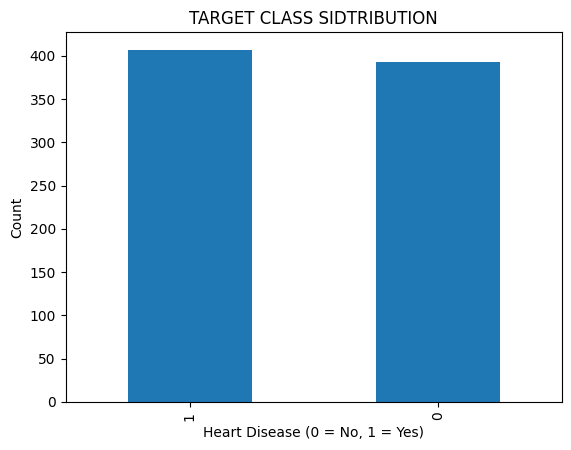

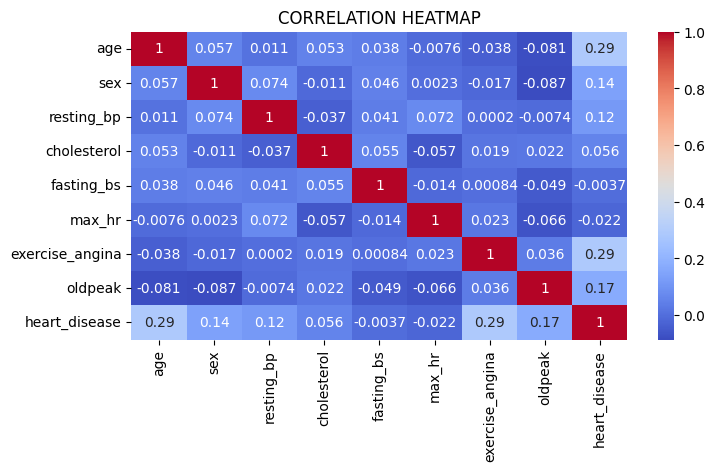

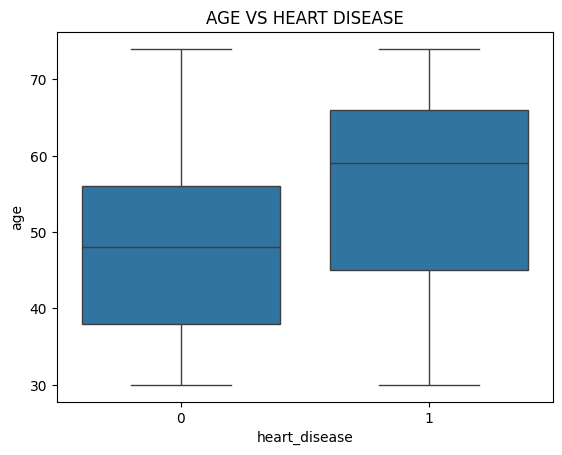

C:\Users\Pranav Bhoir\AppData\Local\Temp\ipykernel_8880\1417618444.py:58: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_columns = df.select_dtypes(include=['object', 'category']).columns


Train shape: (640, 15)
Test shape: (160, 15)

Target distribution (train):
heart_disease
1    0.509375
0    0.490625
Name: proportion, dtype: float64

First few rows of scaled training data:
[[ 0.85247313  0.71624183  0.72223487  1.0505499  -0.55328334  0.59544279
  -0.64978629 -0.15025633 -0.47545099  1.6897993  -0.2847474   1.015749
  -0.76944123 -0.71374643  1.05461425]
 [-1.02077255 -1.39617648  1.41884172 -0.42467232 -0.55328334  2.38519686
   1.53896753  0.1757235  -0.47545099 -0.59178625 -0.2847474   1.015749
  -0.76944123 -0.71374643 -0.948214  ]
 [ 1.55494026  0.71624183 -1.05094623 -1.35639161 -0.55328334  0.05851657
  -0.64978629  0.06706356 -0.47545099 -0.59178625 -0.2847474  -0.98449518
   1.29964442 -0.71374643  1.05461425]
 [-0.08414971  0.71624183  0.65890697 -1.33698079 -0.55328334 -0.47840965
  -0.64978629  0.1757235  -0.47545099 -0.59178625 -0.2847474   1.015749
  -0.76944123  1.4010578  -0.948214  ]
 [-0.55246113 -1.39617648 -1.11427412 -0.63819132 -0.55328334  1.89

In [1]:
##=====Q1 = SUPERVISED LEARNING=======

## TASK-1 DATA LOADING AND INSEPECTION

import pandas as pd

df = pd.read_csv("q1_heart_disease.csv")

print("\nshape of dataset\n")
print(df.shape)

print(" \ndata tupe\n ")
print(df.dtypes)

print("\nmissing values\n ")
print(df.isnull().sum())


print("\nfirst five row\n")
print(df.head())

## TASK-2 EXPLORATORY DATA ANALYSIS

## TAFGET DISTRIBUTION 
import matplotlib.pyplot as plt

df['heart_disease'].value_counts().plot(kind='bar')

plt.title("TARGET CLASS SIDTRIBUTION")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show

## CORRELATION HEATMAP

import seaborn as sns

plt.figure(figsize=(8,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("CORRELATION HEATMAP")
plt.show()

## AGE VS HEART DISEASE

sns.boxplot(x='heart_disease', y='age', data=df)

plt.title("AGE VS HEART DISEASE")
plt.show()

## TASK-3 DATA PREAPROCESSING


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## HANDLE MISSING VALUE 
num_columns = df.select_dtypes(include=['int64', 'float64']).columns
cat_columns = df.select_dtypes(include=['object', 'category']).columns


for c in num_columns:
    missing_count = df[c].isnull().sum()
    if missing_count > 0:
        df[c] = df[c].fillna(df[c].median())

for c in cat_columns:
    if df[c].isnull().sum() > 0:
        most_common = df[c].mode()[0]
        df[c] = df[c].fillna(most_common)


df_ready = pd.get_dummies(df, columns=cat_columns, drop_first=True)


X_all = df_ready.drop('heart_disease', axis=1)
y_all = df_ready['heart_disease']


X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,    
    stratify=y_all,
    random_state=42  
)
## SCALE NUMIRICAL FEATURE
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)


X_test = scaler.transform(X_test)

## TRAIN TEST SPIT

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTarget distribution (train):")
print(y_train.value_counts(normalize=True))

print("\nFirst few rows of scaled training data:")
print(X_train[:5])


## TASK-4 MODEL TRAINING

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


decision_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(random_state=42)
grad_boost = GradientBoostingClassifier(random_state=42)
decision_tree.fit(X_train, y_train)
random_forest.fit(X_train, y_train)


grad_boost.fit(X_train, y_train)

print("MODEL TRAIN SUCCESSFULL")


##TASK-5 MODEL EVALUATION 

from sklearn.metrics import confusion_matrix, classification_report

models_map = {
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "Gradient Boosting": grad_boost
}

for name, mdl in models_map.items():
    print("\n", name)
    
    y_hat = mdl.predict(X_test)
    
    ##CONFUSION MATRIX
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_hat)
    print(cm)
    

    print("\nClassification Report:")
    rep = classification_report(y_test, y_hat)
    print(rep)

 ##TASK-6 HYPERPARAMETER TUNING

from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [58, 116],  
    'max_depth': [3, 5, None]  
}

rf_base = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    rf_base,
    params,
    cv=5,
    scoring='f1'
)

grid_search.fit(X_train, y_train)

print("BEST PARAMS I GOT:", grid_search.best_params_)
